# 18.335 Problem Set 1
Simon Opsahl (sopsahl@mit.edu)

April 6, 2025

In [1]:
using LinearAlgebra, Random, Plots

# Problem 0: Pset Honor Code

I will not look at 18.335 pset solutions from previous semesters. I may discuss problems with my classmates or others, but I will write up my solutions on my own. 

# Problem 1: More on matrices

## part (a)

In this problem, we are asked to prove the following, given that $A \in \mathbb{C}^{n \times n}$.

$$ | \det(A) | ^2 \leq \prod^n_{i=1} \sum^n_{j=1} |a_{ij}|^2 $$

In other words, we must show that the square of the determinant of $A$ is less than or equal to the product of the 2-norms of each row. We can refactor $A$ as 

$$A = U\Sigma V^\ast$$

If we compute $AA^\ast = U \Sigma \Sigma^\ast U^\ast$, we find that 

$$|\det(A) | ^2 = \det(AA^\ast) = \prod_{i=1}^n |\sigma_i|^2$$

given that $\sigma_i$ is a singular value of $A$.

We also know that the diagonal entries of $AA^\ast$ are equal to the sum of squares of each element in given row of $A$. In other words, if $C = AA^\ast$, $C_{i,i} = A_{i,\_} A_{i,\_}^\ast = \sum^n_{j=1} |a_{ij}|^2 $ for a given row $i$.

Finally, we know that the product of diagonal elements of $AA^\ast$ is equivalent to 
$$\prod^n_{i=1}C_{i, i} =  \prod^n_{i=1} \sum^n_{j=1} |a_{ij}|^2 $$ 

and that $|\sigma_i|^2 \le C_{i, i} $. As a result,

$$ | \det(A) | ^2 \leq \prod^n_{i=1} \sum^n_{j=1} |a_{ij}|^2 $$

In [2]:
n = 5
A = rand(Complex{Float64}, n, n)

abs(det(A))^2 <= prod(sum(abs(A[i, j])^2 for j in 1:n) for i in 1:n)

true

## part (b)

In this problem, we are asked to prove the following: given $A \in \mathbb{C}^{n \times n}$ is Hermitian with positive diagonal entries, if $A$ is strictly diagonally dominant or irreducibly diagonally dominant, then $A$ is positive definite. 

In this problem, we must rely on the matrix construction in order to formulate the proof. We know that the diagonal entries are all positive and greater than or equal to the sum of the magnitudes of the other elements in the row. In other words, for $i \in \{1, n\}$,

$$ a_{ii} > 0$$
$$ a_{ii} \ge \sum_{j=1, j\ne i}^n | a_{ij} |  $$

In order to show that $A$ is positive definite, we must show that $A$ is symmetric, which is trivially true by definition of a Hermitian. We must also prove that for $k \in \{1, n\}$, $\lambda_k > 0$.

Consider the $k^{th}$ eigenvalue that satisfies the following expression:

$$ A \hat{x}_k = \lambda_k \hat{x}_k $$

We then simplify to find 

$$ \lambda_k = \hat{x}_k^\ast A \hat{x}_k $$

By definition of a Hermiatian matrix, we know that $\hat{x}_k$ is real and unitary. What is left is showing that $\lambda_k > 0$. Because 

$$ a_{ii} \ge \sum_{j=1, j\ne i}^n | a_{ij} |  $$

the positive diagnoal entries overcome any off-diagonal contribution, and thus $\lambda_k \ge 0 $. When 

$$ a_{ii} > \sum_{j=1, j\ne i}^n | a_{ij} |  $$

for at least one $i$, this ensures that $\lambda_k \ne 0 $. As a result $\lambda_k > 0$.

In [3]:
# Create a satisfying matrix
n = 8

function generate_matrix(strictDominance)
    epsilon = 1e-2

    A = randn(Complex{Float64}, n, n) + im*randn(Complex{Float64}, n, n)

    # make it hermittian
    A = 0.5 * (A + transpose(conj(A)))

    # make diagonal positive and dominant 
    for i in 1:n
        A[i, i] = sum(abs((A[i, j])) for j in 1:n if j!=i)
        if strictDominance
            A[i, i] += epsilon
        end
    end

    # make irredcuible diagnoally dominant
    if strictDominance
        i = rand(1:n)
        A[i, i] += epsilon
    end
    

    return A

end

generate_matrix(true)

8×8 Matrix{ComplexF64}:
   6.82571+0.0im         -0.259931-0.0955499im  …   0.403324+0.582862im
 -0.259931+0.0955499im     4.51655+0.0im            0.563387+0.419732im
  -1.45097-0.730125im     0.657777+0.278323im        1.58196-0.451288im
 -0.627367-0.458943im      1.27259-0.400561im       0.695069+0.302478im
   -1.0115-0.254956im    -0.217772-0.228106im        -1.1872-0.414989im
  0.879746-1.03846im    -0.0198263-0.03908im    …   0.468604-0.266325im
  0.613402+0.820191im     0.645006+0.914995im      -0.521247-0.451133im
  0.403324-0.582862im     0.563387-0.419732im        6.31046+0.0im

In [4]:
# strictly diagnoally dominant

all(isposdef(generate_matrix(true)) for _ in 1:100)

true

In [5]:
# irreducibly diagnoally dominant

all(isposdef(generate_matrix(false)) for _ in 1:100)

true

## part (c)

In this question, given $A \in \mathbb{C}^{n \times n}$ and $A$ is Hermitian positive definite, we are asked to show that $||x||_A = \sqrt{x^\ast A x}$ is a norm over $\mathbb{C}^n$. In order to do so, we must show that $||\cdot ||_A$ satisfies the three following conditions:
1. $||x||_A \ge 0$ and is tight iff $x=0$
2. $||x + y||_A \le ||x||_A + ||y||_A$
3. $||\alpha x||_A = |\alpha| ||x||_A$

I will prove the conditions are satisfied below.

1. $||x||_A \ge 0$ and is tight iff $x=0$

Because $A$ is Hermitian positive definite, we know that we decompose $A$ as $A = U\Lambda U^\ast$, where $U$ is a unitary matrix. We can then rewrite $x^\ast A x$ as 

$$ x^\ast A x = x^\ast U \Lambda U^\ast x = \sum_{i=1}^n \lambda_i (x^\ast U_i)(U_i^\ast x) = \sum_{i=1}^n \lambda_i (U_i^\ast x)^\ast(U_i^\ast x)  $$

Because $\lambda_i >0 , i \in [1, n]$, and the multiplication of complex conjugates is positive and real, $||x||_A = \sqrt{x^\ast A x} \ge 0$. As $\lambda_i \ne 0, U_i \ne \vec{0}, i \in [1, n]$, the expression is zero if and only if $x=0$.

2. $||x + y||_A \le ||x||_A + ||y||_A$

We can square both sides and cancel out like terms to get the inequality 

$$ x^\ast A y + y^\ast A x \le 2 ||x||_A ||y||_A $$

We know that $x^\ast A y  = (y^\ast A x)^\ast$, and thus the sum is real and bounded by twice the magnitudes of the vectors, or

$$ |x^\ast A y| \le  ||x||_A ||y||_A $$

As a result, the triangle inequality holds.

3. $||\alpha x||_A = |\alpha| ||x||_A$

This condition is trivially satisfied. Because $\alpha$ is a scalar, we can input it input the function as follows:

$$||\alpha x||_A = \sqrt{ (\alpha^\ast x^\ast) A (\alpha x) } = \sqrt{ (\alpha^\ast\alpha) (x^\ast A x) } = \sqrt{\alpha^\ast\alpha} \cdot \sqrt{x^\ast A x}  =|\alpha|\cdot ||x||_A  $$

# Problem 2: Solving a System involving Triangular Matrices

In this problem, we are asked to provide an algorithm that solves 

$$ (UV- \lambda I) x =b$$

in $O(n^2)$ operations given that $U, V \in \mathbb{R}^{n \times n}$ and $UV - \lambda I$ is invertible.

We can start by creating two new variables of state: $y$ and $z$. If we posit that $Uy =b$ and $Uz = \lambda x$, we can see that solving

$$ V x = y + z $$

would result in the correct solution for $x$.

The following values will be used as intermediates for clarity of writing: 
    $$ \hat{y}_k = \sum_{j = k+1}^n U_{k, j} y_j$$
    $$ \hat{x}_k = \sum_{j = k+1}^n V_{k, j} x_j$$
    $$ \hat{z}_k = \sum_{j = k+1}^n U_{k, j} z_j$$

The algorithm is as follows:

For $k$ ranging from $n$ to $1$, store 

$$ y_k = \frac{b_k - \hat{y_k}}{U_{k, k}} $$

Then, calculate 

$$ x_k = \frac{b_k - \hat{y_k} - U_{k, k}\hat{x}_k - \hat{z}_k}{U_{k, k}V_{k, k} - \lambda} $$

Finally, store

$$ z_k = \frac{\lambda x_k - \hat{z_k}}{U_{k, k}} $$

For runtime, we see that $2(n -k)$ work is done to calculate each of $\hat{x_k}$, $\hat{y_k}$, and $\hat{z_k}$. Each of the state updates require only a constant number of operations, and thus the total work is 
$$\sum_{k=1}^n [6(n -k) + c] = O(n^2)$$

In [6]:
# Algorithm implementation

function solver(n, U, V, b, lambda)

    y = zeros(n)
    x = zeros(n)
    z = zeros(n)

    hat_y = 0
    hat_x = 0
    hat_z = 0

    for k in n:-1:1
        if k != n
            hat_y = sum(U[k, j] * y[j] for j in k+1:n)
            hat_x = sum(V[k, j] * x[j] for j in k+1:n)
            hat_z = sum(U[k, j] * z[j] for j in k+1:n)
        end
        
        y[k] = (b[k] - hat_y) / U[k, k]

        x[k] = (b[k] - hat_y - U[k, k]*hat_x - hat_z) / (U[k, k] * V[k, k] - lambda)

        z[k] = (lambda * x[k] - hat_z) / U[k, k]

    end

    return x
end

# accuracy check

n = 5
U = UpperTriangular(randn(n, n))
V = UpperTriangular(randn(n, n))
b = randn(n)
lambda = randn()

A = U * V - lambda * I(n)
norm((A \ b) - solver(n, U, V, b, lambda)) < 1e-10

true

# Problem 3: Stationary Iterative Methods

## part (a) 

In this problem, we are given $A \in \mathbb{C}^{n \times n}$ as a Hermitian positive definite matrix. We are told to reduce the following symmetric Gauss-Seidel Method to standard iterative form and show that it converges for all Hermitian positive definite matrices.

$$A = L + D + U$$
$$(D + L)x_{k + \frac{1}{2}}= -Ux_k + b$$
$$(D + U)x_{k}= -Lx_{k+\frac{1}{2}} + b$$

We start by refactoring the first expression and substituting the result into the second.

$$x_{k + \frac{1}{2}}= -(D + L)^{-1}Ux_k + (D + L)^{-1}b$$

$$(D + U)x_{k}= -Lx_{k+\frac{1}{2}} + b = -L[-(D + L)^{-1}Ux_k + (D + L)^{-1}b] + b = L(D + L)^{-1}Ux_k - L(D + L)^{-1}b + b$$

$$x_{k} =(D + U)^{-1}L(D + L)^{-1}Ux_k - (D + U)^{-1}L(D + L)^{-1}b + (D + U)^{-1}b = (D + U)^{-1}L(D + L)^{-1}Ux_k + (D + U)^{-1}(I - L(D + L)^{-1})b $$

As a result, we have found 
$$B = (D + U)^{-1}L(D + L)^{-1}U$$
and 
$$f = (D + U)^{-1}(I - L(D + L)^{-1})b$$
in standard iterative form.

In order to show that this iterative method converges for all Hermitian positive definite matrices, we must show that $\rho (B) < 1$. As a result, we must show that if $\mu$ is an eigenvalue of $B$, $|\mu| < 1$. 

We can solve for the eigenvalues of $B$.

$$ Bx = \mu x$$
$$ L(D + L)^{-1}U x =  \mu (D + U) x $$

$$ L(D + L)^{-1}U x + D(D + L)^{-1}U x = Ux=  \mu (D + U) x +D (D + L)^{-1}U x  $$


$$ (D + L)D^{-1}U x  =  \mu (D + L)D^{-1}(D + U) x + U x  $$
$$ LD^{-1}U x  =  \mu (D + L)D^{-1}(D + U) x = \mu (A+LD^{-1}U) x $$

Now we can multiply both sides by $x^\ast$ to establish bounds on $\mu$. 

$$ x^\ast LD^{-1}U x  =  x^\ast \mu (A+LD^{-1}U) x $$
$$ \mu = \frac{x^\ast LD^{-1}U x}{x^\ast A x + x^\ast LD^{-1}U x } $$

We know that $x^\ast A x > 0$ trivially because it is Hermitian positive definite. We also know that $L= U^\ast$, and thus $ x^\ast LD^{-1}U x = (Ux)^\ast D^{-1}(U x) \ge 0$. As result, 
$$ |\mu| < 1$$

The algorithm converges for all Hermitian positive definite matrices.


## part (b)

In this problem, we are given $A \in \mathbb{C}^{n \times n}$ as a Hermitian positive definite matrix with eigenvalues $\lambda_1 \ge \lambda_2 \ge ... \ge \lambda_n > 0$. We are asked to show that the following iterative method converges when $\omega \in (0, \frac{2}{\lambda_1})$ and to find the optimal $\omega^\ast$ for fastest convergence.

$$ x_{k + 1} = x_k + \omega(b - Ax_k)$$

We start by refactoring the expression to 

$$ x_{k + 1} = (I - \omega A)x_k + \omega b $$

This expression converges iff the spectral radius of $B = I - \omega A$ is less than $1$. We can identify $\mu$ as an eigenvalue of $B$, and define $\mu = 1 - \omega \lambda$. As a result, we can establish bounds on $\omega$. 

$$ | \mu | = | 1 - \omega \lambda | < 1 $$
We find
$$ 1 - \omega \lambda > -1 $$
$$ \omega < \frac{2}{\lambda} < \frac{2}{\lambda_1} $$
and 
$$ 1 - \omega \lambda < 1 $$
$$ \omega > 0 $$


We can find an optimal $\omega^\ast$ by noting that 

$$\rho(B) = \max\{ |1 - \omega \lambda_n|, |1 - \omega \lambda_1 |\} $$

The optimal $\omega^\ast$ is found when these two are equal.

$$ |1 - \omega^\ast \lambda_n| = |1 - \omega^\ast \lambda_1 | $$
$$ 1 - \omega^\ast \lambda_n = \omega^\ast \lambda_1 - 1 $$
$$ \omega^\ast = \frac{2}{\lambda_n + \lambda_1} $$

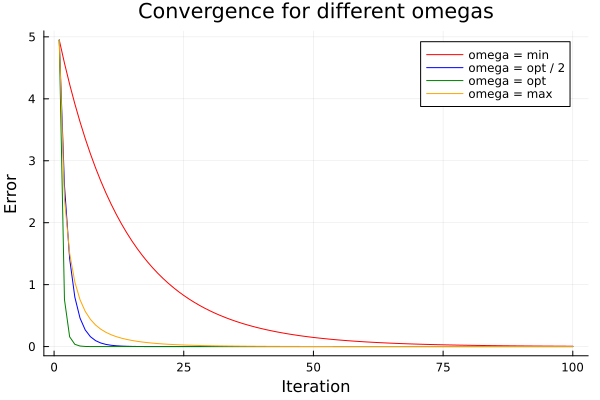

In [7]:
# Implementation
n = 20

# random Hermitian positive definite matrix
A = randn(ComplexF64, n, n)
A = 0.5 * (A + transpose(conj(A)))
A += n * I(n)

# get the eigenvalues
eigs = eigvals(A)
eig_max, eig_min = maximum(eigs), minimum(eigs)

# gets the x values at each step
function check_convergence(A, b, ω)
    x = zeros(ComplexF64, n)
    x_s = Vector{Vector{ComplexF64}}()
    for k in 1:100
        push!(x_s, copy(x))
        x += ω * (b - A * x)
    end
    return x_s
end

x_true = randn(ComplexF64, n)
b = A * x_true

omegas = [0.05* 2/eig_max, 1/(eig_max + eig_min), 2/(eig_max + eig_min), 0.95* 2/eig_max ]
labels = ["min", "opt / 2", "opt", "max"]
colors = [:red, :blue, :green, :orange]
plot()
for (i, omega) in enumerate(omegas)
    x_s = check_convergence(A, b, omega)
    errors = [norm(x - x_true) for x in x_s]
    plot!((errors), label="omega = $(labels[i])", color=colors[i])
end
plot!(legend=:topright)
xlabel!("Iteration")
ylabel!("Error")
title!("Convergence for different omegas")
